In [16]:
import pandas as pd
import numpy as np
df=pd.read_csv('heart.csv')
df

,age,sex,cp,trestbps,chol,fbs,restecg,thalach,exang,oldpeak,slope,ca,thal,target
0,52,1,0,125.0,212,0,NaN,168.0,0,1.0,2,2.0,3.0,0
1,53,1,0,140.0,203,1,0.0,155.0,1,3.1,0,0.0,3.0,0
2,70,1,0,145.0,174,0,1.0,125.0,1,2.6,0,0.0,3.0,0
3,61,1,0,148.0,203,0,1.0,NaN,0,0.0,2,1.0,3.0,0
4,62,0,0,138.0,294,1,1.0,106.0,0,1.9,1,3.0,2.0,0
...,...,...,...,...,...,...,...,...,...,...,...,...,...,...
1020,59,1,1,140.0,221,0,1.0,164.0,1,0.0,2,0.0,2.0,1
1021,60,1,0,125.0,258,0,0.0,141.0,1,2.8,1,1.0,3.0,0
1022,47,1,0,110.0,275,0,0.0,118.0,1,1.0,1,1.0,2.0,0
1023,50,0,0,110.0,254,0,0.0,159.0,0,0.0,2,0.0,2.0,1


In [17]:
df.describe

<bound method NDFrame.describe of       age  sex  cp  trestbps  chol  fbs  restecg  thalach  exang  oldpeak  \
0      52    1   0     125.0   212    0      NaN    168.0      0      1.0   
1      53    1   0     140.0   203    1      0.0    155.0      1      3.1   
2      70    1   0     145.0   174    0      1.0    125.0      1      2.6   
3      61    1   0     148.0   203    0      1.0      NaN      0      0.0   
4      62    0   0     138.0   294    1      1.0    106.0      0      1.9   
...   ...  ...  ..       ...   ...  ...      ...      ...    ...      ...   
1020   59    1   1     140.0   221    0      1.0    164.0      1      0.0   
1021   60    1   0     125.0   258    0      0.0    141.0      1      2.8   
1022   47    1   0     110.0   275    0      0.0    118.0      1      1.0   
1023   50    0   0     110.0   254    0      0.0    159.0      0      0.0   
1024   54    1   0     120.0   188    0      1.0    113.0      0      1.4   

      slope   ca  thal  target  
0       

In [18]:
df.isna().sum()

age         0
sex         0
cp          0
trestbps    1
chol        0
fbs         0
restecg     1
thalach     1
exang       0
oldpeak     0
slope       0
ca          2
thal        1
target      0
dtype: int64

In [19]:
df['trestbps']

0       125.0
1       140.0
2       145.0
3       148.0
4       138.0
        ...  
1020    140.0
1021    125.0
1022    110.0
1023    110.0
1024    120.0
Name: trestbps, Length: 1025, dtype: float64

In [20]:
df['trestbps'].fillna(df['trestbps'].median(),inplace=True)

In [21]:
df['restecg'].fillna(df['restecg'].median(),inplace=True)
df['thalach'].fillna(df['thalach'].median(),inplace=True)
df['ca'].fillna(df['ca'].median(),inplace=True)
df['thal'].fillna(df['thal'].median(),inplace=True)

In [22]:
df

,age,sex,cp,trestbps,chol,fbs,restecg,thalach,exang,oldpeak,slope,ca,thal,target
0,52,1,0,125.0,212,0,1.0,168.0,0,1.0,2,2.0,3.0,0
1,53,1,0,140.0,203,1,0.0,155.0,1,3.1,0,0.0,3.0,0
2,70,1,0,145.0,174,0,1.0,125.0,1,2.6,0,0.0,3.0,0
3,61,1,0,148.0,203,0,1.0,152.0,0,0.0,2,1.0,3.0,0
4,62,0,0,138.0,294,1,1.0,106.0,0,1.9,1,3.0,2.0,0
...,...,...,...,...,...,...,...,...,...,...,...,...,...,...
1020,59,1,1,140.0,221,0,1.0,164.0,1,0.0,2,0.0,2.0,1
1021,60,1,0,125.0,258,0,0.0,141.0,1,2.8,1,1.0,3.0,0
1022,47,1,0,110.0,275,0,0.0,118.0,1,1.0,1,1.0,2.0,0
1023,50,0,0,110.0,254,0,0.0,159.0,0,0.0,2,0.0,2.0,1


In [23]:
from sklearn.preprocessing import LabelEncoder
le = LabelEncoder()
df['sex'] = le.fit_transform(df['sex'])
df['cp'] = le.fit_transform(df['cp'])


In [24]:
X = df.drop('target', axis=1) 
y = df['target']               

In [25]:
from sklearn.utils import resample
df_majority=df[df.target==1]
len(df_majority)

526

In [26]:
df_minority=df[df.target==0]
len(df_minority)

499

In [27]:
df_majority_downsampled=resample(df_majority,
replace=False,
n_samples=len(df_minority),random_state=42)
df_balanced=pd.concat([df_majority_downsampled,df_minority])

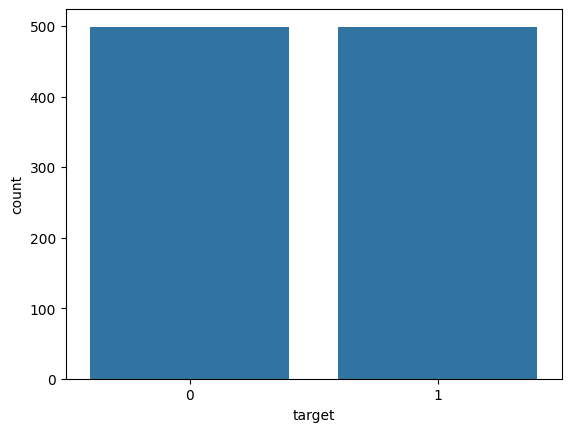

In [28]:
import seaborn as sns
import matplotlib.pyplot as plt
sns.countplot(x='target',data=df_balanced)
plt.show()

In [29]:
from sklearn.model_selection import train_test_split
x_train, x_test, y_train, y_test = train_test_split(X, y, test_size=0.2, random_state=42)


In [30]:
from sklearn.tree import DecisionTreeClassifier

dt = DecisionTreeClassifier(
    criterion='entropy',   
    max_depth=5
)

dt.fit(x_train, y_train)


DecisionTreeClassifier(criterion='entropy', max_depth=5)

In [31]:
y_pred = dt.predict(x_test)


In [32]:
from sklearn.metrics import accuracy_score,classification_report
print('Accuracy : ',round(accuracy_score(y_pred,y_test)*100))
print('Classification Report \n',classification_report(y_pred,y_test))

Accuracy :  82
Classification Report 
               precision    recall  f1-score   support

           0       0.75      0.88      0.81        86
           1       0.90      0.78      0.84       119

    accuracy                           0.82       205
   macro avg       0.82      0.83      0.82       205
weighted avg       0.84      0.82      0.83       205



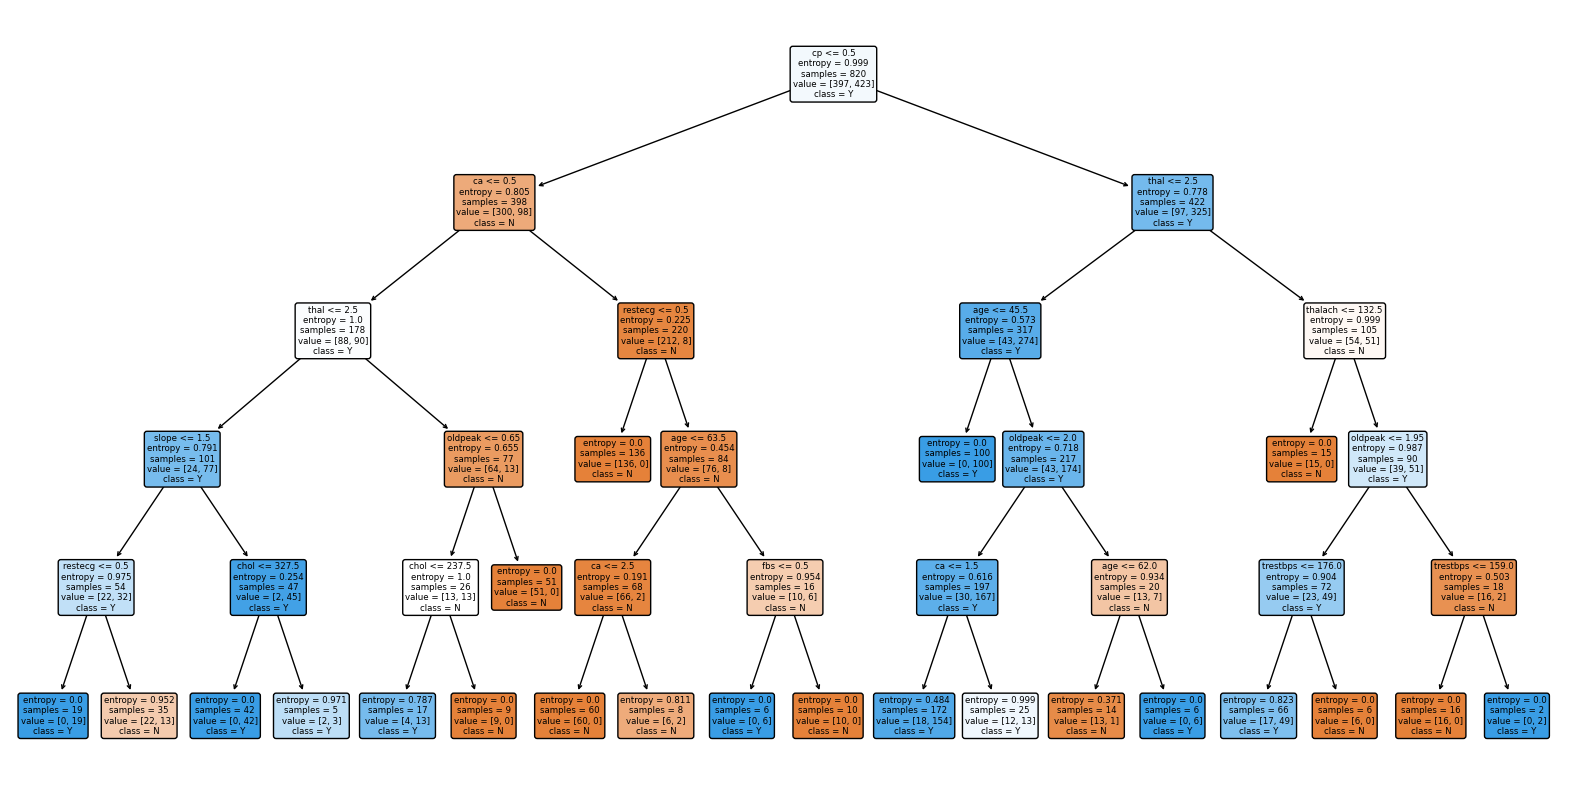

In [33]:
from sklearn.tree import plot_tree
import matplotlib.pyplot as plt
plt.figure(figsize=(20,10))
plot_tree(dt,
          feature_names=X.columns,
          class_names=['N','Y'],
          filled=True,
          rounded=True)
plt.show()

In [34]:
import joblib
joblib.dump(dt,'Hdt.pkl')

['Hdt.pkl']